In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
titanic_data=pd.read_csv("../input/titanic/train.csv")

In [3]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
titanic_data.shape

(891, 12)

<AxesSubplot:>

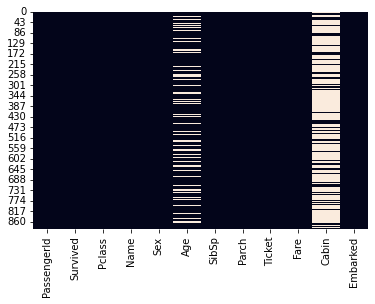

In [6]:
sns.heatmap(titanic_data.isnull(),cbar=False)

In [7]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<AxesSubplot:xlabel='Survived', ylabel='count'>

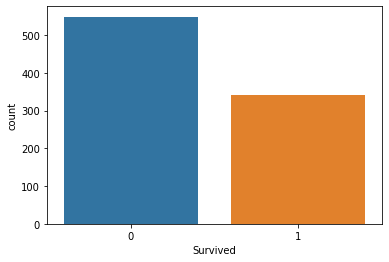

In [8]:
sns.countplot(x='Survived',data=titanic_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

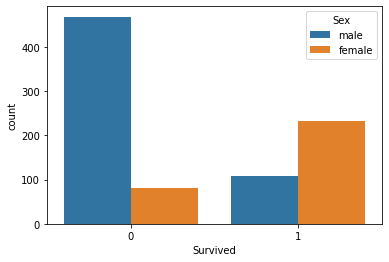

In [9]:
sns.countplot(x='Survived',hue='Sex',data=titanic_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

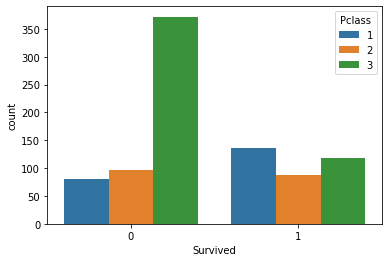

In [10]:
sns.countplot(x='Survived',hue='Pclass',data=titanic_data)

<AxesSubplot:xlabel='Age', ylabel='count'>

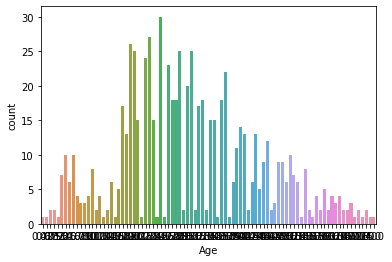

In [11]:
sns.countplot(x='Age',data=titanic_data)

In [12]:
#defining function to fill the null spaces of age
def add_age(cols):
    Age=cols[0]
    Pclass=cols[1]
    if pd.isnull(Age):
        if Pclass==1:
            return titanic_data[titanic_data['Pclass']==1]['Age'].mean()
        elif Pclass==2:
            return titanic_data[titanic_data['Pclass']==2]['Age'].mean()
        elif Pclass==3:
            return titanic_data[titanic_data['Pclass']==3]['Age'].mean()
    else:
        return Age

In [13]:
titanic_data['Age']=titanic_data[['Age','Pclass']].apply(add_age,axis=1)

<AxesSubplot:>

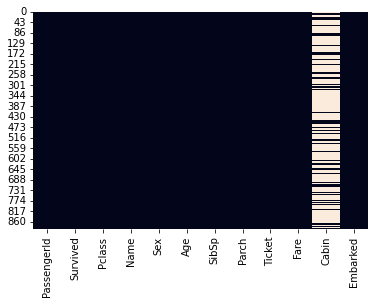

In [14]:
sns.heatmap(titanic_data.isnull(),cbar=False)

In [15]:
titanic_data.drop("Cabin",axis=1,inplace=True)

In [16]:
titanic_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [17]:
titanic_data.Sex=titanic_data.Sex.map({'female':0,'male':1})
titanic_data.Embarked=titanic_data.Embarked.map({'S':0,'C':1,'Q':2})
titanic_data.dropna(inplace=True)

In [18]:
titanic_data.drop(['Name','PassengerId','Ticket'],axis=1,inplace=True)

In [19]:
titanic_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0.0
1,1,1,0,38.0,1,0,71.2833,1.0
2,1,3,0,26.0,0,0,7.9250,0.0
3,1,1,0,35.0,1,0,53.1000,0.0
4,0,3,1,35.0,0,0,8.0500,0.0


In [20]:
x_data=titanic_data.drop('Survived',axis=1)
y_data=titanic_data['Survived']

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_training_data,x_test_data,y_training_data,y_test_data=train_test_split(x_data,y_data,test_size=0.2,random_state=0,stratify=y_data)

In [23]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [24]:
model.fit(x_training_data,y_training_data)
predictions=model.predict(x_test_data)

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test_data,predictions))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88       110
           1       0.81      0.79      0.80        68

    accuracy                           0.85       178
   macro avg       0.84      0.84      0.84       178
weighted avg       0.85      0.85      0.85       178



In [26]:
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test_data,predictions))

Accuracy: 0.848314606741573


In [27]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test_data,predictions)
print(cm)

[[97 13]
 [14 54]]


<AxesSubplot:>

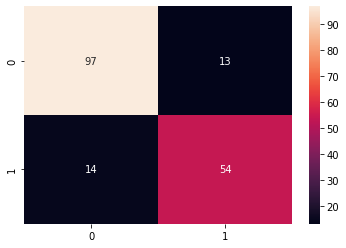

In [28]:
sns.heatmap(cm,annot=True)

In [29]:
df=pd.read_csv("../input/titanic/test.csv")

In [30]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [31]:
df.shape

(418, 11)

<AxesSubplot:>

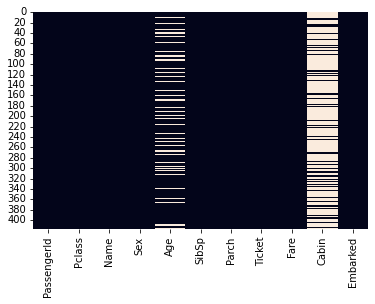

In [32]:
sns.heatmap(df.isnull(),cbar=False)

In [33]:
df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<AxesSubplot:xlabel='Pclass', ylabel='count'>

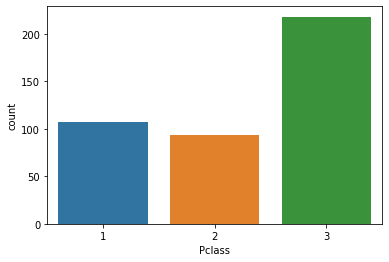

In [34]:
sns.countplot(x='Pclass',data=df)

In [35]:
def add_age(cols):
    Age=cols[0]
    Pclass=cols[1]
    if pd.isnull(Age):
        if Pclass==1:
            return df[df['Pclass']==1]['Age'].mean()
        elif Pclass==2:
            return df[df['Pclass']==2]['Age'].mean()
        elif Pclass==3:
            return df[df['Pclass']==3]['Age'].mean()
    else:
        return Age

In [36]:
df['Age']=df[['Age','Pclass']].apply(add_age,axis=1)

In [37]:
df.drop(['Cabin'],axis=1,inplace=True)

In [38]:
df['Fare']=df['Fare'].fillna(df['Fare'].mean())

In [39]:
df2=df.drop(['Name','PassengerId','Ticket'],axis=1)

In [40]:
df2.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [41]:
df2.Sex=df.Sex.map({'female':0,'male':1})
df2.Embarked=df.Embarked.map({'S':0,'C':1,'Q':2})

In [42]:
prediction=model.predict(df2)
prediction

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,

In [43]:
submission = pd.DataFrame({"PassengerId": df["PassengerId"],"Survived": prediction})
submission.to_csv('submission.csv', index=False)

In [44]:
prediction_data=pd.read_csv("submission.csv")

<AxesSubplot:xlabel='Survived', ylabel='count'>

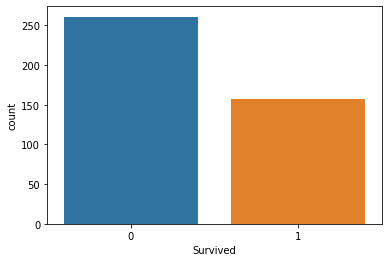

In [45]:
sns.countplot(x='Survived', data=prediction_data)